<a href="https://colab.research.google.com/github/Jishnumathi/Journal-Quartile-Verification-Agent/blob/main/VOIS_Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VOIS–AICTE Batch 1 2026–2027 Major Project
# Seasonal Agriculture Performance Analysis

**Objective:** Analyze how agricultural performance varies across seasons and investigate relationships among crop choice, environmental conditions, resource usage, productivity, profitability, and agricultural risk.

**Dataset:** `seasonal_agriculture_performance_dataset.csv`

This notebook is designed to be **fully executable**, evidence-driven, and suitable for submission/presentation. It avoids unsupported causal claims and uses normalized metrics such as yield/ha and profit/ha where appropriate.

In [ ]:
# 1. Setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = "/content/drive/MyDrive/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


## 2. Dataset Understanding

In [ ]:
# Basic structure
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique()
}).sort_values(["missing", "unique"], ascending=[False, False]))

display(df.describe(include="all").T)

Rows: 4000
Columns: 28


,dtype,missing,unique
Rainfall_mm,float64,48,3256
Soil_Moisture_pct,float64,40,343
Yield_Tonnes_Ha,float64,32,738
Farm_ID,object,0,4000
Total_Cost_INR,int64,0,3995
Revenue_INR,int64,0,3993
Profit_INR,int64,0,3992
Market_Price_INR_Tonne,int64,0,3760
Water_Used_m3,int64,0,3407
Water_Efficiency_t_per_1000m3,float64,0,3127


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.000",NaN,NaN,NaN,7.888,4.224,0.500,4.260,7.895,11.650,15.000
Rainfall_mm,"3,952.000",NaN,NaN,NaN,601.153,288.925,80.000,370.200,582.000,834.950,"1,395.200"
Avg_Temperature_C,"4,000.000",NaN,NaN,NaN,26.819,3.818,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",NaN,NaN,NaN,63.211,11.961,25.000,54.775,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",NaN,NaN,NaN,7.323,1.121,3.500,6.600,7.300,8.100,11.000


## 3. Data Quality Checks

In [ ]:
# Duplicate and missing-value checks
print("Duplicate rows:", df.duplicated().sum())
print("\nTotal missing values:", int(df.isna().sum().sum()))

# Try to identify numeric columns and inspect impossible/negative values
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
display(negative_counts[negative_counts > 0].to_frame("negative_values"))

Duplicate rows: 0

Total missing values: 120


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.000",7.888,4.224,0.500,4.260,7.895,11.650,15.000
Rainfall_mm,"3,952.000",601.153,288.925,80.000,370.200,582.000,834.950,"1,395.200"
Avg_Temperature_C,"4,000.000",26.819,3.818,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",63.211,11.961,25.000,54.775,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",7.323,1.121,3.500,6.600,7.300,8.100,11.000
Soil_pH,"4,000.000",6.701,0.641,5.200,6.260,6.690,7.140,8.400
Soil_Moisture_pct,"3,960.000",26.508,6.712,8.000,21.700,26.400,31.300,47.000
Nitrogen_kg_ha,"4,000.000",120.251,31.216,40.000,98.500,120.100,141.225,220.000
Phosphorus_kg_ha,"4,000.000",57.782,17.015,15.000,46.200,57.500,69.400,120.000
Potassium_kg_ha,"4,000.000",104.760,27.743,30.000,86.200,105.100,123.600,200.000


,negative_values
Profit_INR,1966


## 4. Data Preparation and Derived Metrics

For fair comparisons between farms of different sizes, this analysis uses:
- **Yield per hectare**
- **Production per hectare**
- **Profit per hectare**
- **Water efficiency**

Existing dataset columns are detected automatically where possible.

In [ ]:
# Normalize column names for robust matching
original_columns = df.columns.tolist()
print("Columns:")
for c in original_columns:
    print("-", c)

def find_col(candidates):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    # relaxed matching
    for c in df.columns:
        cl = str(c).strip().lower()
        for candidate in candidates:
            if candidate.lower() in cl:
                return c
    return None

season_col = find_col(["Season"])
crop_col = find_col(["Crop"])
state_col = find_col(["State"])
district_col = find_col(["District"])
area_col = find_col(["Farm Area", "Area"])
yield_col = find_col(["Yield"])
production_col = find_col(["Production"])
profit_col = find_col(["Profit"])
revenue_col = find_col(["Revenue"])
cost_col = find_col(["Cost", "Total Cost"])
water_col = find_col(["Water Used", "Water Usage", "Water"])
efficiency_col = find_col(["Water Efficiency"])
risk_col = find_col(["Disease/Pest Risk", "Disease Pest Risk", "Risk"])

print("Detected columns:")
for name, col in {
    "season": season_col, "crop": crop_col, "state": state_col,
    "district": district_col, "area": area_col, "yield": yield_col,
    "production": production_col, "profit": profit_col, "revenue": revenue_col,
    "cost": cost_col, "water": water_col, "water_efficiency": efficiency_col,
    "risk": risk_col
}.items():
    print(f"{name:20s}: {col}")

# Create normalized metrics when possible.
if area_col and yield_col:
    # If yield is already explicitly per hectare, this would duplicate the measure.
    # The dataset used for this project stores Yield as tonnes/ha, so retain it.
    df["Yield_per_ha"] = pd.to_numeric(df[yield_col], errors="coerce")

if area_col and production_col:
    df["Production_per_ha"] = (
        pd.to_numeric(df[production_col], errors="coerce") /
        pd.to_numeric(df[area_col], errors="coerce").replace(0, np.nan)
    )

if area_col and profit_col:
    df["Profit_per_ha"] = (
        pd.to_numeric(df[profit_col], errors="coerce") /
        pd.to_numeric(df[area_col], errors="coerce").replace(0, np.nan)
    )

# Use the dataset's existing water-efficiency measure if available.
if efficiency_col:
    df["Water_Efficiency"] = pd.to_numeric(df[efficiency_col], errors="coerce")

display(df.head())

Columns:
- Farm_ID
- State
- District
- Crop
- Season
- Farm_Area_Hectares
- Rainfall_mm
- Avg_Temperature_C
- Humidity_pct
- Sunlight_Hours_Day
- Soil_pH
- Soil_Moisture_pct
- Nitrogen_kg_ha
- Phosphorus_kg_ha
- Potassium_kg_ha
- Irrigation_Method
- Fertilizer_kg_ha
- Pesticide_Litre_ha
- Seed_Quality_Score
- Yield_Tonnes_Ha
- Production_Tonnes
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Profit_INR
- Water_Used_m3
- Water_Efficiency_t_per_1000m3
- Disease_Pest_Risk_pct
Detected columns:
season              : Season
crop                : Crop
state               : State
district            : District
area                : Farm_Area_Hectares
yield               : Yield_Tonnes_Ha
production          : Production_Tonnes
profit              : Profit_INR
revenue             : Revenue_INR
cost                : Total_Cost_INR
water               : Water_Used_m3
water_efficiency    : None
risk                : Disease_Pest_Risk_pct


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Yield_per_ha,Production_per_ha,Profit_per_ha
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300,2.460,2.453,"-22,362.264"
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900,0.300,0.300,"-69,211.332"
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700,0.520,0.521,"-25,667.490"
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600,1.840,1.840,"-21,267.556"
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300,2.210,2.209,"-34,287.886"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Seasonal Overview

In [ ]:
season_summary = df.groupby(season_col).agg(
    Farms=(season_col, "size"),
    Avg_Yield=("Yield_per_ha", "mean"),
    Avg_Profit=(profit_col, "mean") if profit_col else (season_col, "size"),
    Avg_Profit_per_ha=("Profit_per_ha", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency", "mean") if "Water_Efficiency" in df else (season_col, "size"),
).reset_index()

# Add risk separately when available
if risk_col:
    risk_numeric = pd.to_numeric(df[risk_col], errors="coerce")
    df["_risk_numeric"] = risk_numeric
    risk_summary = df.groupby(season_col)["_risk_numeric"].mean().reset_index(name="Avg_Risk")
    season_summary = season_summary.merge(risk_summary, on=season_col, how="left")

display(season_summary.sort_values("Avg_Yield", ascending=False))

,Season,Farms,Avg_Yield,Avg_Profit,Avg_Profit_per_ha,Avg_Water_Efficiency,Avg_Risk
0,Kharif,1779,5.644,"178,914.648","21,881.810",1779,54.468
1,Rabi,1627,5.080,"87,689.470","10,361.680",1627,40.482
2,Zaid,594,4.666,"-24,804.825","-2,636.522",594,38.217


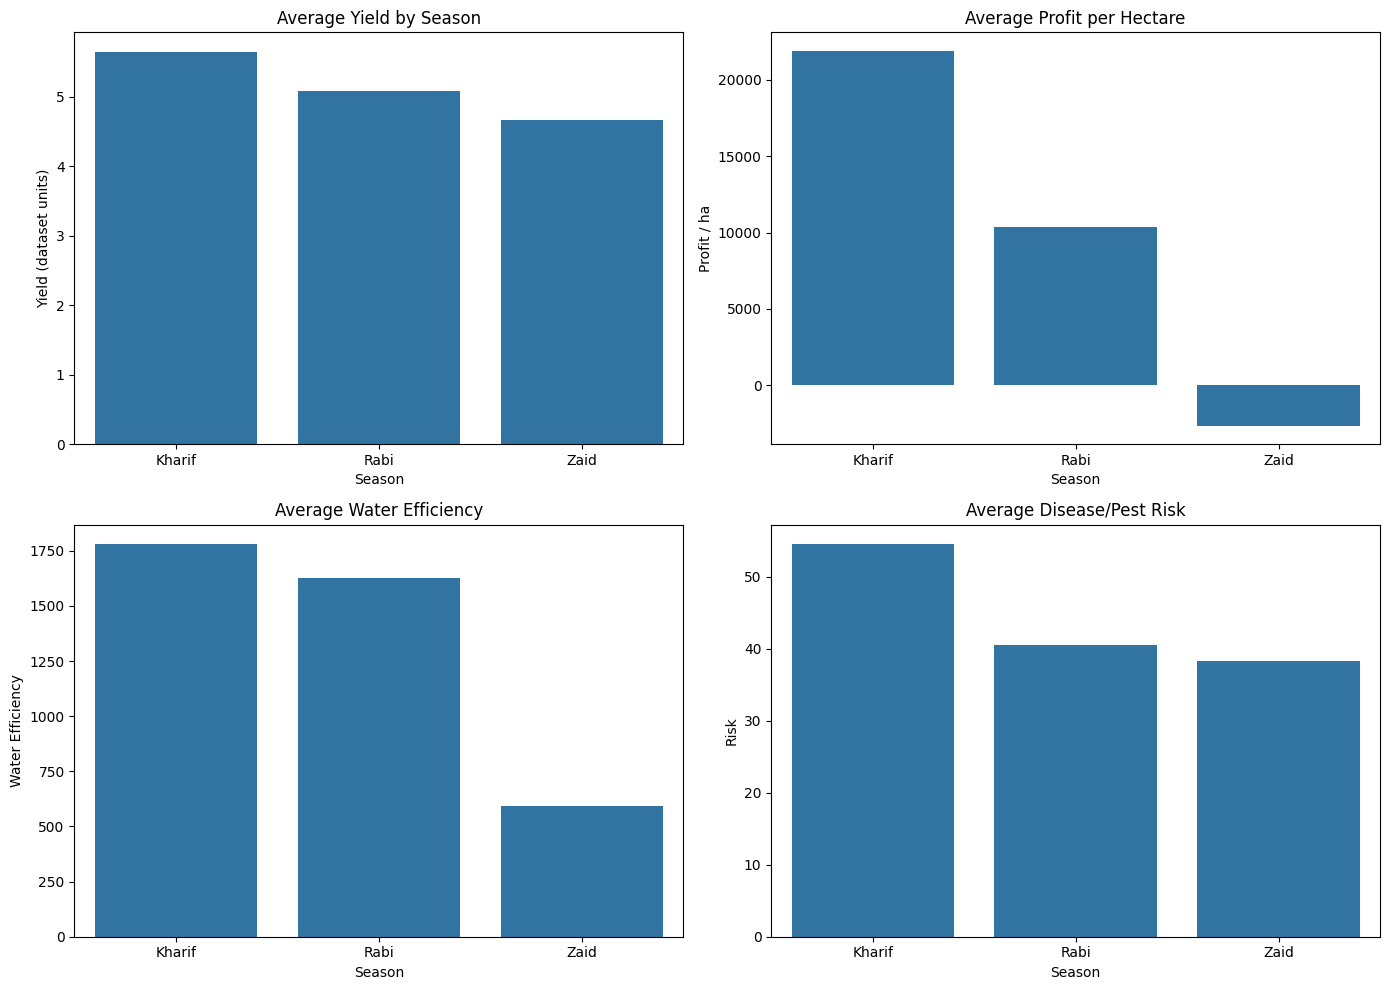

In [ ]:
# Seasonal performance charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=season_summary, x=season_col, y="Avg_Yield", ax=axes[0,0])
axes[0,0].set_title("Average Yield by Season")
axes[0,0].set_ylabel("Yield (dataset units)")

sns.barplot(data=season_summary, x=season_col, y="Avg_Profit_per_ha", ax=axes[0,1])
axes[0,1].set_title("Average Profit per Hectare")
axes[0,1].set_ylabel("Profit / ha")

sns.barplot(data=season_summary, x=season_col, y="Avg_Water_Efficiency", ax=axes[1,0])
axes[1,0].set_title("Average Water Efficiency")
axes[1,0].set_ylabel("Water Efficiency")

if "Avg_Risk" in season_summary:
    sns.barplot(data=season_summary, x=season_col, y="Avg_Risk", ax=axes[1,1])
    axes[1,1].set_title("Average Disease/Pest Risk")
    axes[1,1].set_ylabel("Risk")
else:
    axes[1,1].axis("off")

plt.tight_layout()
plt.show()

## 6. Crop × Season Analysis

,Season,Crop,Farms,Avg_Yield,Avg_Profit_per_ha,Avg_Production_per_ha
6,Kharif,Sugarcane,125,53.459,"120,564.287",53.459
3,Kharif,Maize,234,2.966,"-4,968.277",2.966
5,Kharif,Rice,314,2.708,"-7,986.976",2.707
7,Kharif,Wheat,292,2.255,"-13,181.570",2.251
0,Kharif,Chilli,185,1.731,"111,812.028",1.726
2,Kharif,Groundnut,193,1.484,"16,870.943",1.482
1,Kharif,Cotton,215,1.373,"27,343.103",1.373
4,Kharif,Pulses,221,1.036,"7,043.550",1.036
14,Rabi,Sugarcane,129,43.940,"86,013.497",43.955
11,Rabi,Maize,233,2.615,"-11,776.240",2.616


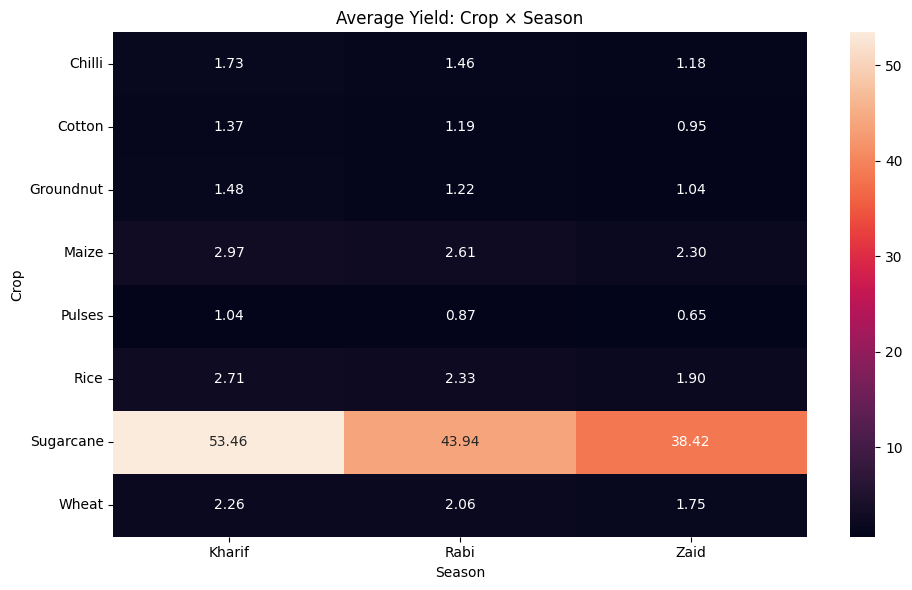

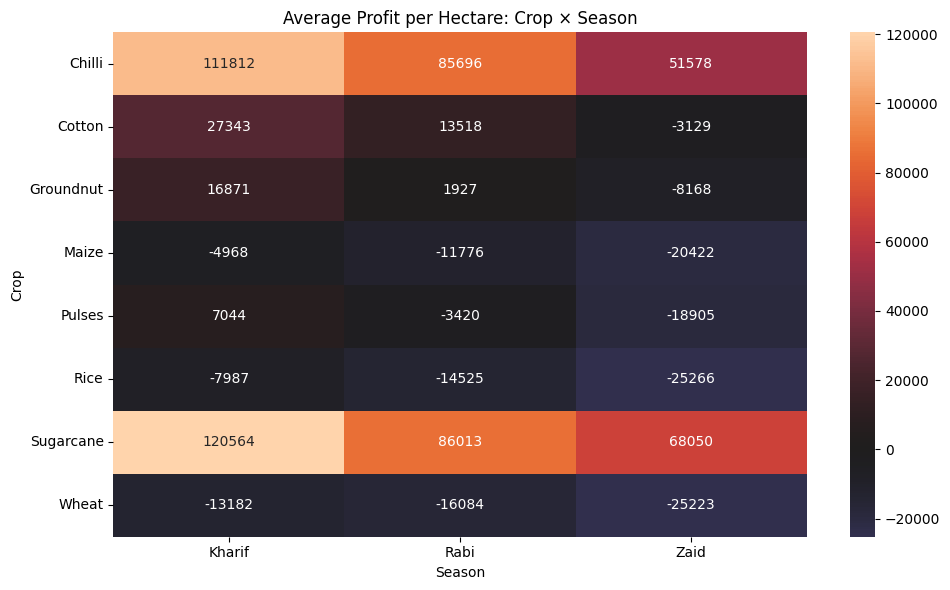

In [ ]:
crop_season = df.groupby([season_col, crop_col]).agg(
    Farms=(crop_col, "size"),
    Avg_Yield=("Yield_per_ha", "mean"),
    Avg_Profit_per_ha=("Profit_per_ha", "mean"),
    Avg_Production_per_ha=("Production_per_ha", "mean")
).reset_index()

display(crop_season.sort_values(["Season", "Avg_Yield"], ascending=[True, False]))

yield_pivot = crop_season.pivot(index=crop_col, columns=season_col, values="Avg_Yield")
plt.figure(figsize=(10, 6))
sns.heatmap(yield_pivot, annot=True, fmt=".2f")
plt.title("Average Yield: Crop × Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

profit_pivot = crop_season.pivot(index=crop_col, columns=season_col, values="Avg_Profit_per_ha")
plt.figure(figsize=(10, 6))
sns.heatmap(profit_pivot, annot=True, fmt=".0f", center=0)
plt.title("Average Profit per Hectare: Crop × Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

## 7. Environmental Factors vs Yield

,Variable,Pearson_r,p_value,N
0,Rainfall_mm,0.031,0.053,3920
3,Sunlight_Hours_Day,-0.015,0.333,3968
2,Humidity_pct,0.011,0.478,3968
1,Avg_Temperature_C,0.009,0.556,3968


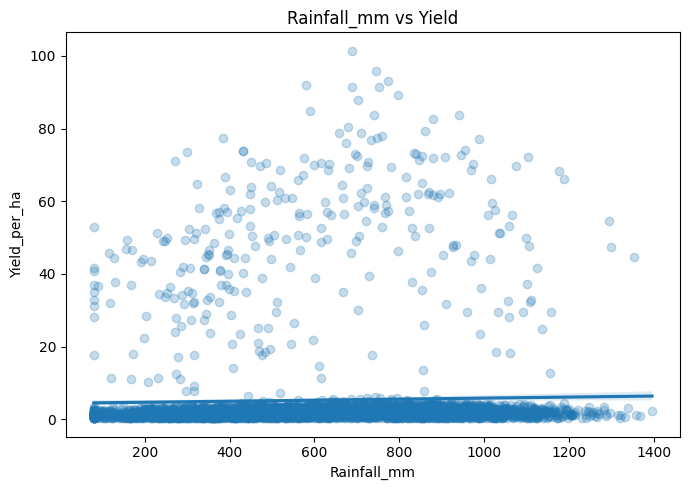

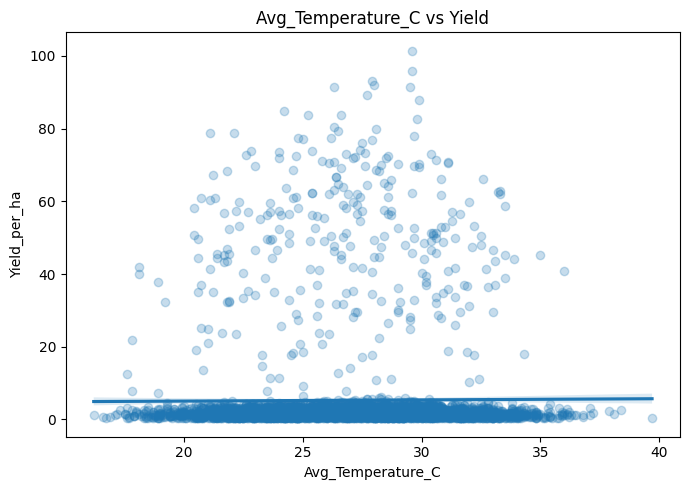

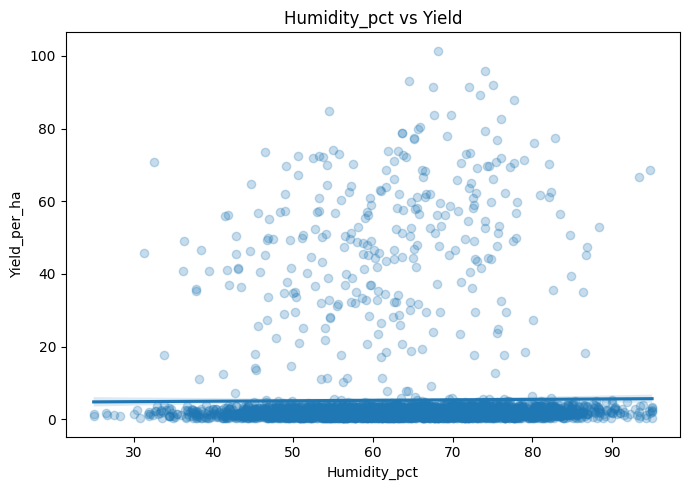

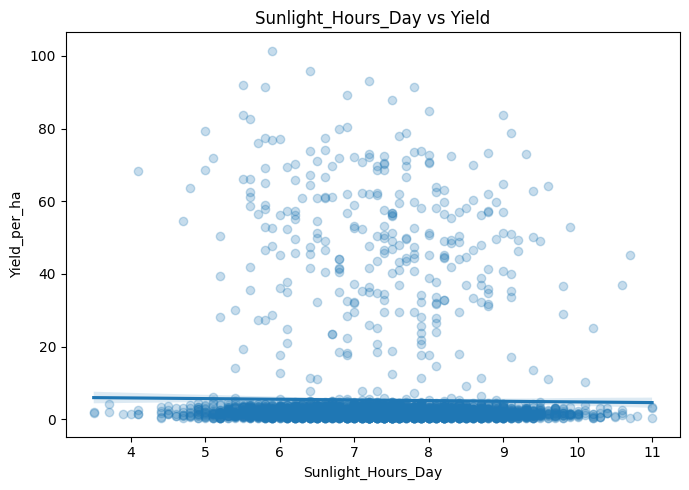

In [ ]:
# Automatically identify likely environmental variables
environment_candidates = [
    "Rainfall", "Temperature", "Humidity", "Sunlight",
    "Soil pH", "Soil Moisture", "Soil Moisture Content"
]
environment_cols = [find_col([x]) for x in environment_candidates]
environment_cols = [x for x in environment_cols if x is not None]

corr_rows = []
for col in environment_cols:
    x = pd.to_numeric(df[col], errors="coerce")
    y = pd.to_numeric(df["Yield_per_ha"], errors="coerce")
    valid = pd.concat([x, y], axis=1).dropna()
    if len(valid) > 2:
        r, p = stats.pearsonr(valid.iloc[:,0], valid.iloc[:,1])
        corr_rows.append([col, r, p, len(valid)])

env_corr = pd.DataFrame(corr_rows, columns=["Variable", "Pearson_r", "p_value", "N"])
display(env_corr.sort_values("Pearson_r", key=lambda s: s.abs(), ascending=False))

for col in environment_cols:
    plt.figure(figsize=(7, 5))
    sns.regplot(data=df, x=col, y="Yield_per_ha", scatter_kws={"alpha": 0.25})
    plt.title(f"{col} vs Yield")
    plt.tight_layout()
    plt.show()

## 8. Resource Usage vs Performance

,Resource,Pearson_r_with_Yield,p_value,N
2,Nitrogen_kg_ha,0.054,0.001,3968
3,Phosphorus_kg_ha,0.048,0.003,3968
1,Pesticide_Litre_ha,-0.008,0.630,3968
4,Potassium_kg_ha,0.004,0.809,3968
0,Fertilizer_kg_ha,0.001,0.972,3968


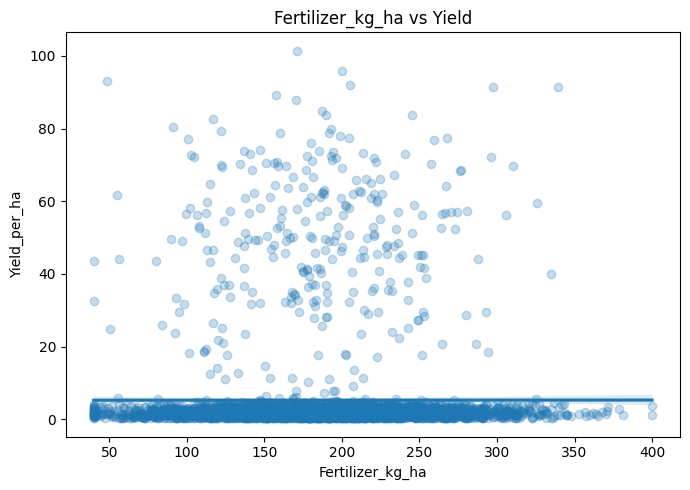

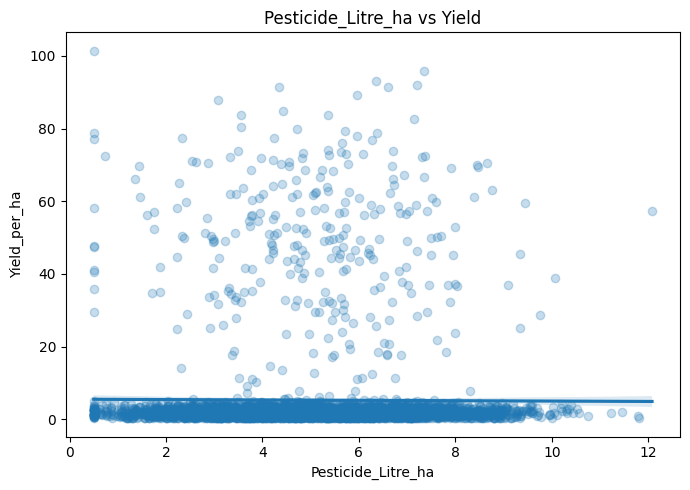

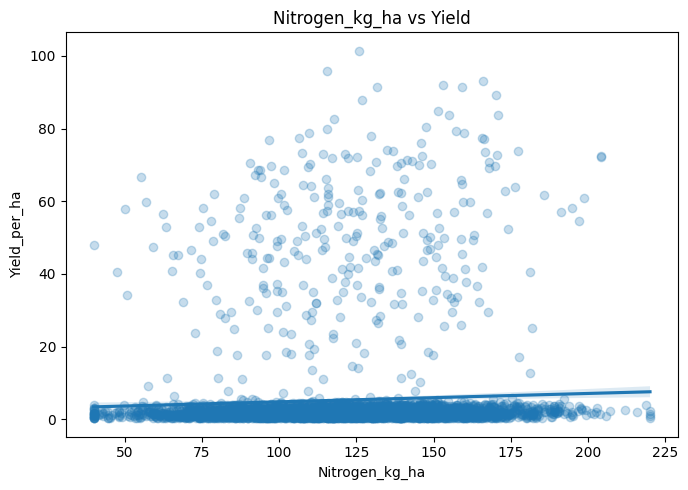

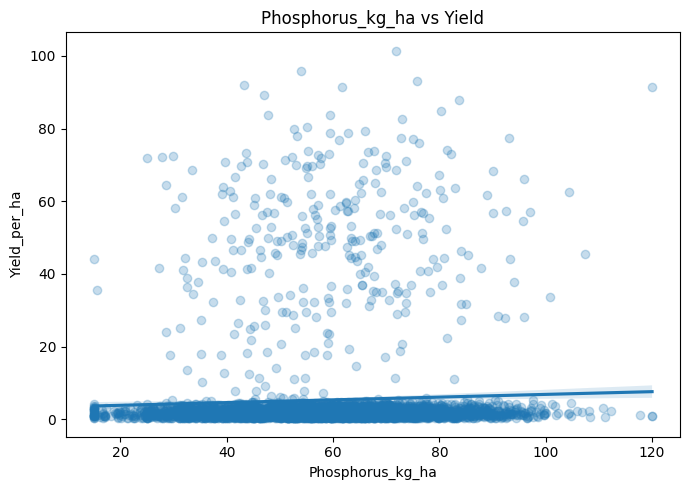

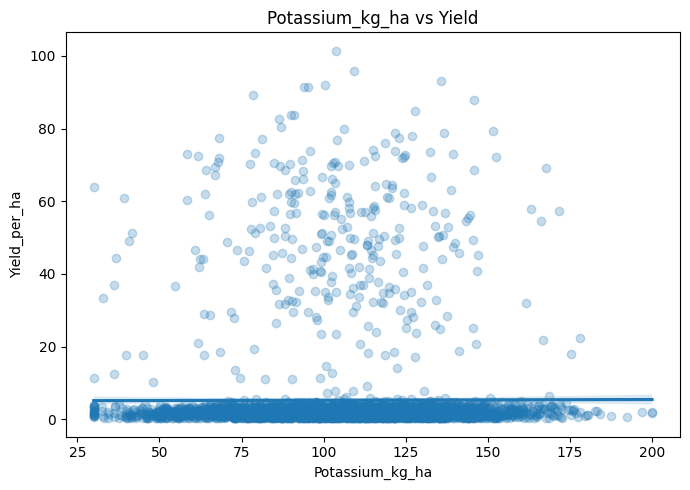

In [ ]:
resource_candidates = [
    "Water Used", "Water Usage", "Fertilizer", "Pesticide",
    "Nitrogen", "Phosphorus", "Potassium"
]
resource_cols = [find_col([x]) for x in resource_candidates]
resource_cols = [x for x in resource_cols if x is not None]

resource_corr_rows = []
for col in resource_cols:
    x = pd.to_numeric(df[col], errors="coerce")
    y = pd.to_numeric(df["Yield_per_ha"], errors="coerce")
    valid = pd.concat([x, y], axis=1).dropna()
    if len(valid) > 2:
        r, p = stats.pearsonr(valid.iloc[:,0], valid.iloc[:,1])
        resource_corr_rows.append([col, r, p, len(valid)])

resource_corr = pd.DataFrame(
    resource_corr_rows,
    columns=["Resource", "Pearson_r_with_Yield", "p_value", "N"]
)
display(resource_corr.sort_values("Pearson_r_with_Yield", key=lambda s: s.abs(), ascending=False))

for col in resource_cols:
    plt.figure(figsize=(7, 5))
    sns.regplot(data=df, x=col, y="Yield_per_ha", scatter_kws={"alpha": 0.25})
    plt.title(f"{col} vs Yield")
    plt.tight_layout()
    plt.show()

## 9. Economic Performance

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,"710,719.060","531,804.410","178,914.650"
Rabi,"601,526.050","513,836.580","87,689.470"
Zaid,"519,171.900","543,976.730","-24,804.820"


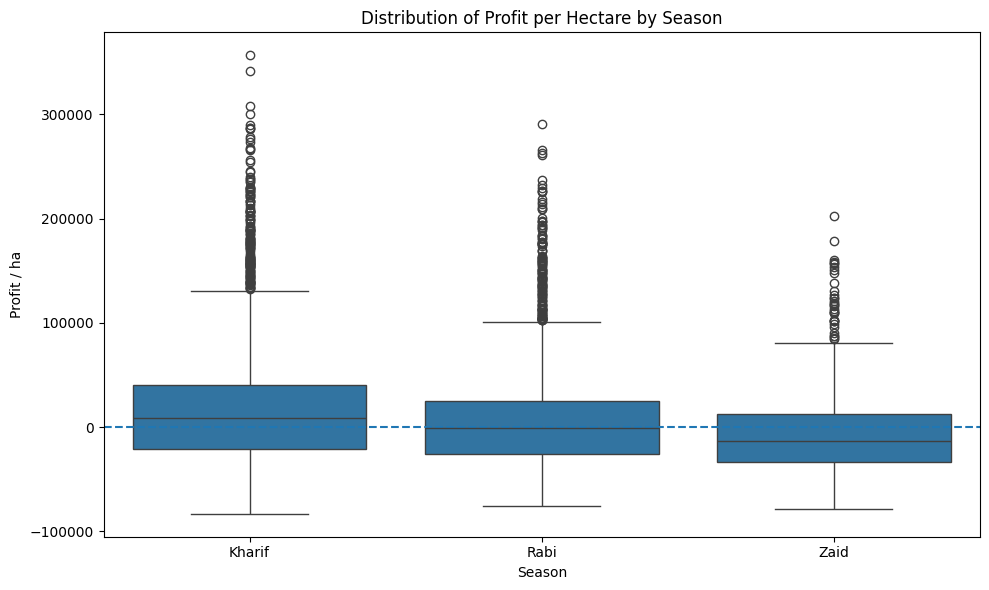

In [ ]:
economic_cols = [c for c in [revenue_col, cost_col, profit_col] if c is not None]

if economic_cols:
    economic_summary = df.groupby(season_col)[economic_cols].mean().round(2)
    display(economic_summary)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=season_col, y="Profit_per_ha")
plt.axhline(0, linestyle="--")
plt.title("Distribution of Profit per Hectare by Season")
plt.ylabel("Profit / ha")
plt.tight_layout()
plt.show()

## 10. Regional Analysis

,State,Farms,Avg_Yield,Avg_Profit_per_ha,Avg_Water_Efficiency
5,Punjab,484,6.121,"15,776.793",6.121
2,Karnataka,489,5.734,"14,843.755",5.734
1,Gujarat,488,5.700,"12,992.588",5.700
7,Telangana,516,5.077,"15,054.884",5.077
4,Maharashtra,512,5.030,"14,899.928",5.030
3,Madhya Pradesh,497,5.030,"11,058.187",5.030
6,Tamil Nadu,485,4.901,"12,927.049",4.901
0,Andhra Pradesh,529,4.651,"11,006.673",4.651


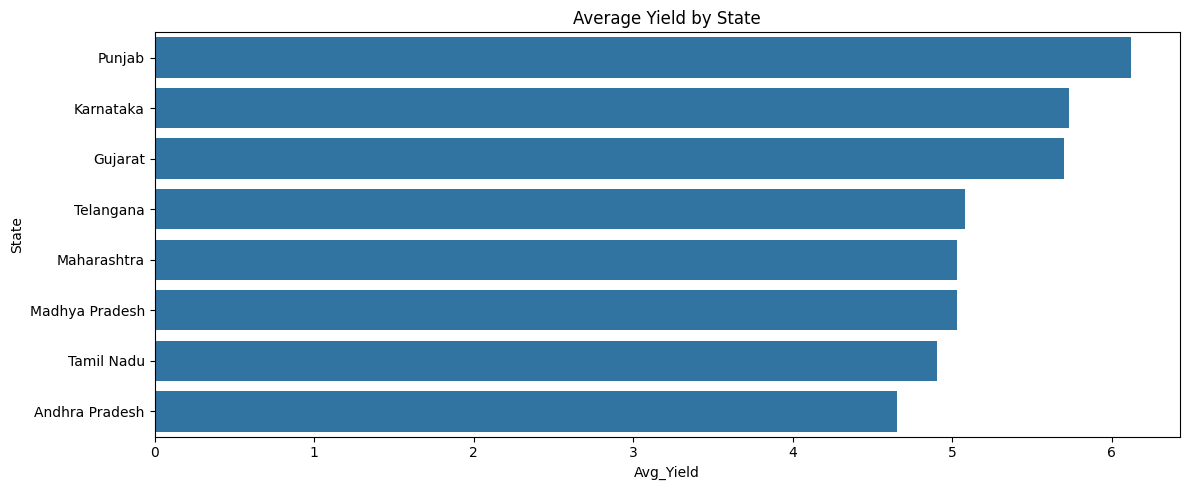

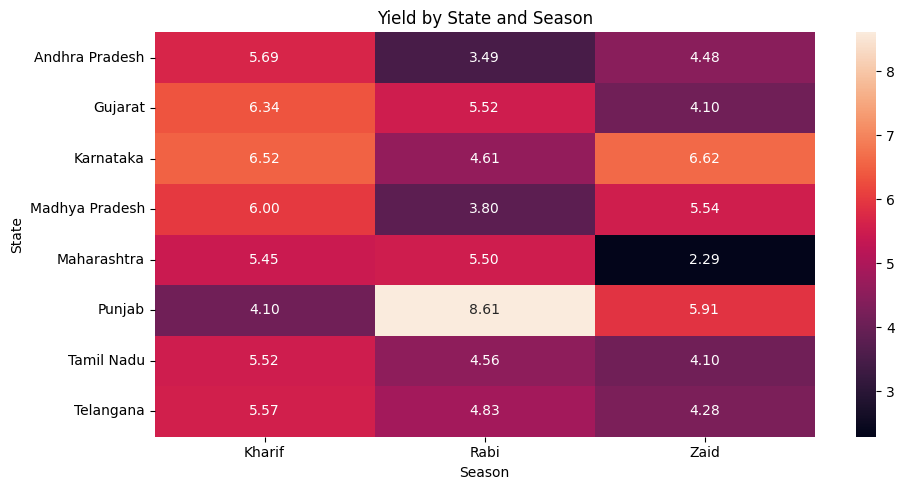

In [ ]:
if state_col:
    state_summary = df.groupby(state_col).agg(
        Farms=(state_col, "size"),
        Avg_Yield=("Yield_per_ha", "mean"),
        Avg_Profit_per_ha=("Profit_per_ha", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency", "mean") if "Water_Efficiency" in df else ("Yield_per_ha", "mean")
    ).reset_index().sort_values("Avg_Yield", ascending=False)

    display(state_summary)

    plt.figure(figsize=(12, max(5, 0.35 * len(state_summary))))
    sns.barplot(data=state_summary, y=state_col, x="Avg_Yield")
    plt.title("Average Yield by State")
    plt.tight_layout()
    plt.show()

    state_season = df.groupby([state_col, season_col])["Yield_per_ha"].mean().reset_index()
    state_season_pivot = state_season.pivot(index=state_col, columns=season_col, values="Yield_per_ha")
    plt.figure(figsize=(10, max(5, 0.35 * len(state_season_pivot))))
    sns.heatmap(state_season_pivot, annot=True, fmt=".2f")
    plt.title("Yield by State and Season")
    plt.tight_layout()
    plt.show()
else:
    print("State column not found; skipping regional analysis.")

## 11. Statistical Test: Do Seasons Differ in Yield?

In [ ]:
# One-way ANOVA across seasons
groups = [
    g["Yield_per_ha"].dropna().values
    for _, g in df.groupby(season_col)
    if g["Yield_per_ha"].notna().sum() > 1
]

if len(groups) >= 2:
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value: {p_value:.6g}")

    if p_value < 0.05:
        print("Interpretation: There is statistically significant evidence that mean yield differs across at least some seasons.")
    else:
        print("Interpretation: The data does not provide sufficient evidence of a difference in mean yield across seasons.")
else:
    print("Insufficient groups for ANOVA.")

ANOVA F-statistic: 1.4580
ANOVA p-value: 0.232835
Interpretation: The data does not provide sufficient evidence of a difference in mean yield across seasons.


## 12. Outlier and Anomaly Analysis

In [ ]:
# IQR-based anomaly detection for key metrics
def iqr_outliers(data, column):
    s = pd.to_numeric(data[column], errors="coerce")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return data.loc[mask].copy(), (low, high)

for metric in ["Yield_per_ha", "Profit_per_ha", "Water_Efficiency"]:
    if metric in df:
        outliers, bounds = iqr_outliers(df, metric)
        print(f"\n{metric}: {len(outliers)} IQR outliers; bounds = {bounds}")
        display(outliers[[c for c in [season_col, crop_col, state_col, area_col, metric] if c]].head(10))

# High water + low yield candidates
if water_col:
    water_num = pd.to_numeric(df[water_col], errors="coerce")
    yield_num = pd.to_numeric(df["Yield_per_ha"], errors="coerce")
    high_water = water_num >= water_num.quantile(0.75)
    low_yield = yield_num <= yield_num.quantile(0.25)
    candidates = df.loc[high_water & low_yield].copy()
    print("\nHigh-water / low-yield candidates:", len(candidates))
    display(candidates[[c for c in [season_col, crop_col, state_col, water_col, "Yield_per_ha", "Profit_per_ha"] if c]].head(15))


Yield_per_ha: 302 IQR outliers; bounds = (-1.6349999999999996, 5.5249999999999995)


,Season,Crop,State,Farm_Area_Hectares,Yield_per_ha
47,Zaid,Sugarcane,Punjab,7.680,36.690
75,Kharif,Sugarcane,Maharashtra,10.640,62.580
79,Zaid,Sugarcane,Karnataka,9.290,33.550
82,Rabi,Sugarcane,Andhra Pradesh,2.460,49.520
92,Kharif,Sugarcane,Gujarat,12.740,70.230
113,Rabi,Sugarcane,Tamil Nadu,14.350,58.060
132,Kharif,Sugarcane,Telangana,3.830,29.470
154,Kharif,Sugarcane,Telangana,9.120,47.880
155,Kharif,Sugarcane,Madhya Pradesh,4.500,62.090
164,Rabi,Sugarcane,Telangana,4.000,36.910



Profit_per_ha: 284 IQR outliers; bounds = (-110277.95876384526, 116186.64588258672)


,Season,Crop,State,Farm_Area_Hectares,Profit_per_ha
9,Rabi,Chilli,Tamil Nadu,13.690,"142,792.915"
75,Kharif,Sugarcane,Maharashtra,10.640,"157,493.421"
78,Rabi,Chilli,Madhya Pradesh,10.000,"163,339.800"
87,Kharif,Chilli,Madhya Pradesh,5.720,"138,387.587"
88,Kharif,Chilli,Andhra Pradesh,13.290,"154,782.619"
92,Kharif,Sugarcane,Gujarat,12.740,"190,556.672"
113,Rabi,Sugarcane,Tamil Nadu,14.350,"161,974.286"
125,Rabi,Chilli,Maharashtra,8.450,"147,546.864"
133,Rabi,Chilli,Telangana,5.690,"155,502.109"
150,Rabi,Chilli,Punjab,2.990,"160,596.656"



High-water / low-yield candidates: 161


,Season,Crop,State,Water_Used_m3,Yield_per_ha,Profit_per_ha
32,Kharif,Cotton,Madhya Pradesh,9585,0.640,"-22,805.110"
42,Kharif,Rice,Karnataka,7926,0.900,"-55,825.871"
49,Rabi,Rice,Madhya Pradesh,15881,0.760,"-69,301.932"
70,Rabi,Cotton,Maharashtra,9888,1.000,"-3,526.698"
104,Zaid,Wheat,Gujarat,9826,0.300,"-78,471.301"
122,Rabi,Rice,Madhya Pradesh,8874,0.660,"-45,821.290"
146,Rabi,Cotton,Telangana,10714,0.660,"-34,404.774"
149,Kharif,Groundnut,Telangana,9248,0.720,"-30,538.817"
153,Kharif,Rice,Punjab,8937,0.730,"-34,897.436"
165,Kharif,Wheat,Andhra Pradesh,10261,0.300,"-60,003.053"


## 13. Multivariate Yield Model — Exploratory, Not Causal

MAE: 1.510384382871537
R²: 0.8762967148969574


,Feature,Importance
18,cat__Crop_Sugarcane,0.796
0,num__Rainfall_mm,0.048
6,num__Nitrogen_kg_ha,0.030
2,num__Humidity_pct,0.024
7,num__Phosphorus_kg_ha,0.016
1,num__Avg_Temperature_C,0.016
4,num__Fertilizer_kg_ha,0.015
8,num__Potassium_kg_ha,0.013
5,num__Pesticide_Litre_ha,0.012
3,num__Sunlight_Hours_Day,0.008


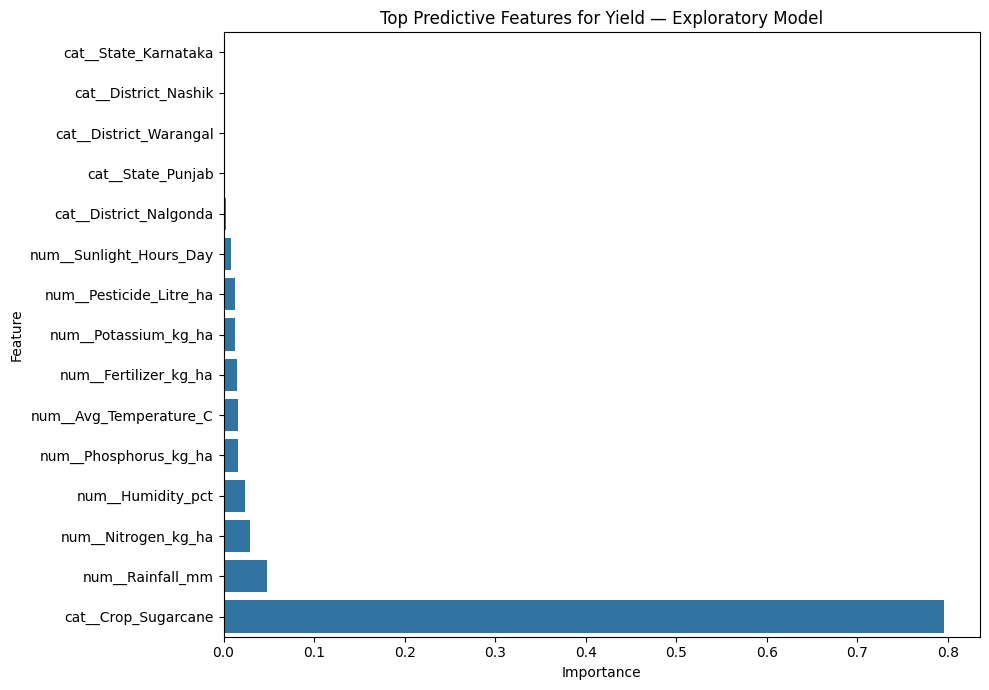

In [ ]:
# Build an interpretable predictive model to identify potentially important variables.
# This is used for analytical exploration, not causal inference.

target = "Yield_per_ha"

candidate_features = []
for c in [season_col, crop_col, state_col, district_col] + environment_cols + resource_cols:
    if c is not None and c not in candidate_features and c != target:
        candidate_features.append(c)

model_df = df[candidate_features + [target]].copy()
model_df = model_df.dropna(subset=[target])

# Keep only features with at least 2 distinct values
candidate_features = [c for c in candidate_features if model_df[c].nunique(dropna=True) >= 2]

X = model_df[candidate_features]
y = model_df[target]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R²:", r2_score(y_test, pred))

# Feature importance
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
top = importance_df.head(15).sort_values("Importance")
sns.barplot(data=top, x="Importance", y="Feature")
plt.title("Top Predictive Features for Yield — Exploratory Model")
plt.tight_layout()
plt.show()

## 14. Evidence-Based Findings Generator

In [ ]:
# Generate concise, data-derived observations for the final report.
best_yield_season = season_summary.loc[season_summary["Avg_Yield"].idxmax(), season_col]
worst_yield_season = season_summary.loc[season_summary["Avg_Yield"].idxmin(), season_col]

print("KEY FINDINGS")
print("-" * 70)
print(f"1. Highest average yield season: {best_yield_season}")
print(f"2. Lowest average yield season: {worst_yield_season}")

best_profit_season = season_summary.loc[season_summary["Avg_Profit_per_ha"].idxmax(), season_col]
print(f"3. Highest average profit/ha season: {best_profit_season}")

if "Avg_Risk" in season_summary:
    highest_risk_season = season_summary.loc[season_summary["Avg_Risk"].idxmax(), season_col]
    print(f"4. Highest average disease/pest risk season: {highest_risk_season}")

if not env_corr.empty:
    strongest_env = env_corr.iloc[env_corr["Pearson_r"].abs().argmax()]
    print(f"5. Strongest absolute environmental correlation with yield: "
          f"{strongest_env['Variable']} (r={strongest_env['Pearson_r']:.3f}, p={strongest_env['p_value']:.4g})")

if not resource_corr.empty:
    strongest_resource = resource_corr.iloc[resource_corr["Pearson_r_with_Yield"].abs().argmax()]
    print(f"6. Strongest absolute resource correlation with yield: "
          f"{strongest_resource['Resource']} "
          f"(r={strongest_resource['Pearson_r_with_Yield']:.3f}, p={strongest_resource['p_value']:.4g})")

print("\nImportant: correlations and predictive feature importance indicate association/predictive usefulness, not causation.")

KEY FINDINGS
----------------------------------------------------------------------
1. Highest average yield season: Kharif
2. Lowest average yield season: Zaid
3. Highest average profit/ha season: Kharif
4. Highest average disease/pest risk season: Kharif
5. Strongest absolute environmental correlation with yield: Rainfall_mm (r=0.031, p=0.05342)
6. Strongest absolute resource correlation with yield: Nitrogen_kg_ha (r=0.054, p=0.0006873)

Important: correlations and predictive feature importance indicate association/predictive usefulness, not causation.


## 15. Final VOIS Project Conclusions

Use the generated evidence above to finalize the report. The recommended interpretation framework is:

1. **Seasonal performance:** identify which season has the strongest productivity and economic outcomes.
2. **Trade-offs:** identify whether stronger productivity comes with higher risk or resource consumption.
3. **Crop composition:** compare crops within seasons so that overall seasonal averages are not misleading.
4. **Environmental relationships:** report correlation strength honestly; weak correlations are valid findings.
5. **Resource efficiency:** examine water and input usage alongside yield rather than in isolation.
6. **Economic performance:** prioritize profit/ha and other normalized measures for farm-level comparisons.
7. **Regional variation:** identify locations where seasonal patterns differ from the overall trend.
8. **Anomalies:** investigate high-resource/low-output and high-risk cases.
9. **Statistical evidence:** use ANOVA and other tests to distinguish observable patterns from statistically supported differences.
10. **Recommendations:** make recommendations only where the dataset provides evidence, and label areas requiring further investigation.

### Final project message

> **Seasonal agricultural performance is a multi-factor outcome. The analysis demonstrates that meaningful differences can be observed across seasons, but those differences need to be interpreted alongside crop choice, resource utilization, environmental conditions, regional variation, economic performance and risk. This provides a data-driven foundation for more informed seasonal agricultural planning.**